In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from os.path import join, isfile, isdir
from os import listdir

In [3]:
# parent_path = "/data/cschmidt/excited_states/data_forces/fr0_data_correct_energies/additional_forces"
parent_path = '/data/cschmidt/excited_states/force_NNs/fr0_project/correct_energies/trained_all_10_sol_improved_traj'

n_atoms = 45

In [13]:
# list all the files in the directory
# files = [f for f in listdir(parent_path) if isfile(join(parent_path, f))]

files = ['train_all_10_improved_traj.dat']

In [6]:
forces_list, energies_list = [], []
# extract the energies and oscillator strenghts from the files
for file in files:
    # read the file
    with open(join(parent_path, file), "r") as f:
        lines = f.readlines()

    filename = file.split("_")[1]

    # extract the energies and oscillator strengths
    # the first line of the excitation block contains the excitation energy and the oscillator strength
    # the following n_atoms are just the coordinates + 1 empty line
    energies_solvent = []
    forces_solvent = []

    # extract the energies and oscillator strengths
    for i in range(len(lines)):
        if i % (n_atoms + 2) == 0:
            if lines[i].strip():
                energies = lines[i].strip().split()
                energy = np.sum([float(energy) for energy in energies])
                energies_solvent.append(energy)
        else:
            if lines[i].strip():
                line = lines[i].strip().split()
                forces = line[-3:]
                forces = np.array([float(force) for force in forces])
                forces_solvent.append(forces)
    
    energies_list.append(np.array(energies_solvent))
    forces_list.append(np.array(forces_solvent))

In [7]:
print(forces_list[0].shape)
forces_sum_list = [np.sum(forces, axis=1) for forces in forces_list]

print(forces_sum_list[0].shape)

for forces in forces_list:
    print(forces.shape[1])

(12538395, 3)
(12538395,)
3


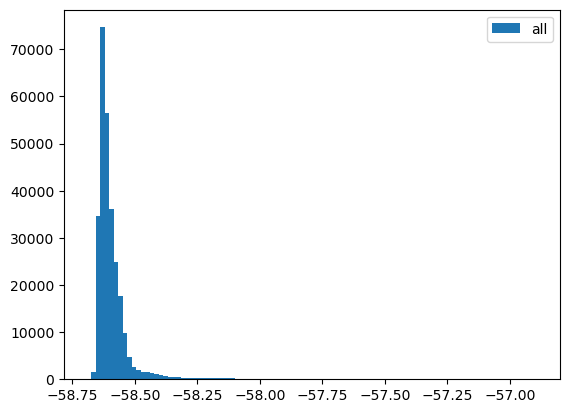

In [14]:
for n, (energies, solvent) in enumerate(zip(energies_list, files)):
    solvent_name = solvent.split("_")[1]
    plt.hist(energies, bins=100, label=solvent_name) #, histtype="step")
# plt.title(f"Solvent: {solvent_name}")
plt.legend()
plt.show()

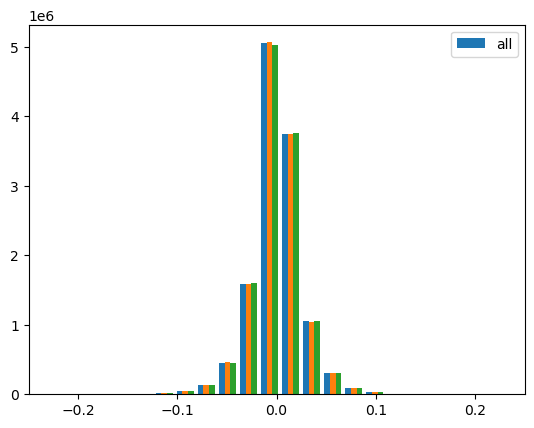

In [15]:
for n, (forces, solvent) in enumerate(zip(forces_list, files)):
    solvent_name = solvent.split("_")[1]
    plt.hist(forces, bins=1000, label=solvent_name) #, histtype="step")
# plt.title(f"Solvent: {solvent_name}")
plt.xlim(-0.25, 0.25)
plt.legend()
plt.show()